# Sydney House Price Estimation under Market Shift

**UTS 32513 Machine Learning — Assignment A2 (Option 2: build an ML system for a practical challenge)**

Student: Hangyu Hu — ID: 14735221 — Year: 2026

---

## Notebook outline

| # | Section | Maps to A2 criterion |
|---|---------|----------------------|
| 0 | Environment setup | Submission requirement (self-contained) |
| 1 | Data acquisition & first look | A — Task definition (input spec) |
| 2 | Data cleaning & task definition | A — Task definition |
| 3 | Temporal train / validation / test split | C — Proper validation scheme |
| 4 | Evaluation metrics (PPE10, MdAPE, RMSE) & naive baselines | C — Evaluation |
| 5 | Model 1: Ridge regression | B — Model & algorithm |
| 6 | Model 2: Gradient boosting (LightGBM) | B — Model & algorithm |
| 7 | Model 3: MLP (PyTorch) | B — Model & algorithm |
| 8 | Ablations: log target, split strategy, suburb encoding, macro features | B / C |
| 9 | Loss vs. task objective; quantile regression | C — Evaluation & refinement |
| 10 | Error analysis & research question | C — Evaluation & refinement |

> Sections 2–10 are added step by step. This notebook currently contains sections 0–1.

## 0. Environment setup

The A2 specification requires the notebook to be **self-contained**: environment setup, data download and preprocessing must all happen inside the notebook so that a reviewer can press *Run all* on Google Colab.

Everything used here is available on a default Colab runtime except `lightgbm`, which is installed below (the install is skipped if the package is already present).

In [1]:
import importlib, subprocess, sys

def ensure(pkg: str, import_name: str | None = None) -> None:
    """Install `pkg` with pip only if `import_name` cannot be imported."""
    try:
        importlib.import_module(import_name or pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure("lightgbm")

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

print("python  ", sys.version.split()[0])
print("pandas  ", pd.__version__)
print("numpy   ", np.__version__)
print("sklearn ", sklearn.__version__)
print("torch   ", torch.__version__)

python   3.11.14
pandas   2.1.4
numpy    1.26.4
sklearn  1.2.2
torch    2.12.0


## 1. Data acquisition and first look

### 1.1 Source

`domain_properties.csv` — 11,160 residential property sales in Greater Sydney (Jan 2016 – Jan 2022) scraped from Domain.com.au, enriched with suburb-level census statistics and two macro-economic series (RBA cash rate, property price index). Original dataset: *Sydney House Prices*, Kaggle user `alexlau203`, https://www.kaggle.com/datasets/alexlau203/sydney-house-prices

The cell below first looks for a local copy (for offline development) and otherwise downloads the file from `DATA_URL`, a public copy in this project's GitHub repository, so the notebook runs on a fresh Colab session.

In [2]:
import urllib.request
from pathlib import Path

DATA_URL = "https://raw.githubusercontent.com/AlexHu1210/uts-ml-a2-sydney-house-price/main/data/domain_properties.csv"

LOCAL_CANDIDATES = [Path("../data/domain_properties.csv"), Path("data/domain_properties.csv")]
TARGET = Path("domain_properties.csv")

def get_data_path() -> Path:
    for p in LOCAL_CANDIDATES:
        if p.exists():
            print(f"Using local copy: {p.resolve()}")
            return p
    if not TARGET.exists():
        print(f"Downloading from {DATA_URL} ...")
        urllib.request.urlretrieve(DATA_URL, TARGET)
    print(f"Using downloaded copy: {TARGET.resolve()}")
    return TARGET

raw = pd.read_csv(get_data_path())
print("shape:", raw.shape)
raw.head()

Using local copy: /Users/huhangyu/PycharmProjects/32513/data/domain_properties.csv
shape: (11160, 17)


,price,date_sold,suburb,num_bath,num_bed,num_parking,property_size,type,suburb_population,suburb_median_income,suburb_sqkm,suburb_lat,suburb_lng,suburb_elevation,cash_rate,property_inflation_index,km_from_cbd
0,530000,13/1/16,Kincumber,4,4,2,1351,House,7093,29432,9.914,-33.47252,151.40208,24,2.0,150.9,47.05
1,525000,13/1/16,Halekulani,2,4,2,594,House,2538,24752,1.397,-33.21772,151.55237,23,2.0,150.9,78.54
2,480000,13/1/16,Chittaway Bay,2,4,2,468,House,2028,31668,1.116,-33.32678,151.44557,3,2.0,150.9,63.59
3,452000,13/1/16,Leumeah,1,3,1,344,House,9835,32292,4.055,-34.05375,150.83957,81,2.0,150.9,40.12
4,365500,13/1/16,North Avoca,0,0,0,1850,Vacant land,2200,45084,1.497,-33.45608,151.43598,18,2.0,150.9,49.98


### 1.2 What is in the table?

This is **not** exploratory analysis for decoration. Each check below answers a question that the *task definition* (criterion A) needs:

1. What is the type, unit and value range of every input column? (needed for a *Clear*-level input specification)
2. Are there missing values? (decides whether an imputation step is part of the system)
3. How are sales distributed over time? (decides the train/validation/test split)
4. What property types are present? (decides which rows are inside the scope of the task)

In [3]:
# (1) column types and value ranges
summary = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_unique": raw.nunique(),
    "n_missing": raw.isna().sum(),
    "min": raw.min(numeric_only=True),
    "median": raw.median(numeric_only=True),
    "max": raw.max(numeric_only=True),
})
summary

,dtype,n_unique,n_missing,min,median,max
cash_rate,float64,14,0,0.10000,1.100000e-01,2.000000e+00
date_sold,object,1338,0,NaN,NaN,NaN
km_from_cbd,float64,595,0,0.31000,2.231000e+01,8.479000e+01
num_bath,int64,17,0,0.00000,2.000000e+00,4.600000e+01
num_bed,int64,25,0,0.00000,4.000000e+00,4.700000e+01
num_parking,int64,20,0,0.00000,2.000000e+00,5.000000e+01
price,int64,2186,0,225000.00000,1.388000e+06,6.000000e+07
property_inflation_index,float64,23,0,150.90000,1.766000e+02,2.201000e+02
property_size,int64,1620,0,7.00000,6.000000e+02,5.910000e+04
suburb,object,637,0,NaN,NaN,NaN


In [4]:
# (3) distribution of sales over time
raw["date_sold"] = pd.to_datetime(raw["date_sold"], format="%d/%m/%y")

print("date range:", raw["date_sold"].min().date(), "->", raw["date_sold"].max().date())
print("\nsales per year:")
print(raw["date_sold"].dt.year.value_counts().sort_index().to_string())

# macro series over time — are they really time-varying?
macro = raw.groupby(raw["date_sold"].dt.year)[["cash_rate", "property_inflation_index"]].agg(["min", "max"])
print("\ncash rate and price index by year:")
print(macro.to_string())

date range: 2016-01-13 -> 2022-01-01

sales per year:
date_sold
2016    1031
2017     998
2018    1010
2019    1159
2020    1632
2021    5328
2022       2

cash rate and price index by year:
          cash_rate       property_inflation_index       
                min   max                      min    max
date_sold                                                
2016           1.50  2.00                    150.9  172.7
2017           1.50  1.50                    171.9  176.6
2018           1.50  1.50                    154.2  171.9
2019           0.75  1.50                    153.5  169.6
2020           0.10  0.75                    165.9  183.1
2021           0.10  0.10                    183.1  220.1
2022           0.10  0.10                    220.1  220.1


In [5]:
# (4) property types and suburb coverage
print(raw["type"].value_counts().to_string())
print("\nnumber of suburbs:", raw["suburb"].nunique())
print("sales per suburb — median:", raw["suburb"].value_counts().median(),
      "| min:", raw["suburb"].value_counts().min(),
      "| max:", raw["suburb"].value_counts().max())

type
House                            9583
Apartment / Unit / Flat           688
Townhouse                         211
Semi-Detached                     170
Vacant land                       163
Villa                             114
Duplex                             67
Terrace                            63
Block of Units                     37
Acreage / Semi-Rural               21
New House & Land                   15
New Apartments / Off the Plan       9
Development Site                    7
Studio                              5
Rural                               4
New land                            3

number of suburbs: 637
sales per suburb — median: 16.0 | min: 1 | max: 68


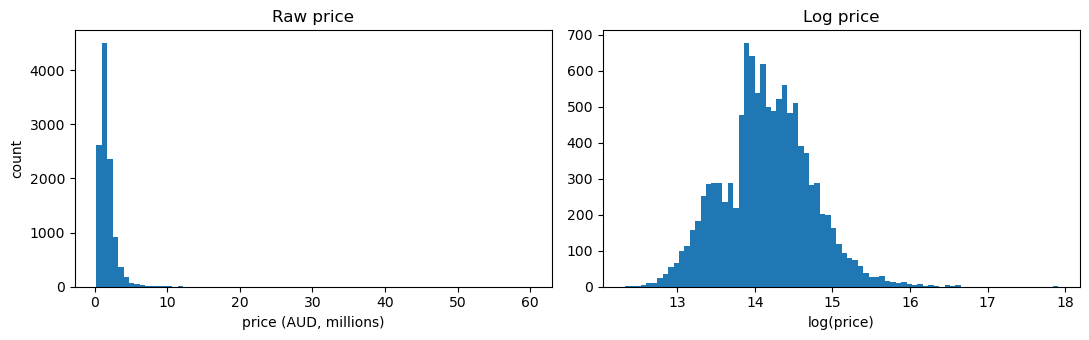

count        11,160
mean      1,675,395
std       1,290,371
min         225,000
25%       1,002,000
50%       1,388,000
75%       2,020,000
max      60,000,000


In [6]:
# Target distribution: raw price vs log price.
# This single figure motivates two later design decisions (log target, relative-error metric).
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(raw["price"] / 1e6, bins=80)
ax[0].set_xlabel("price (AUD, millions)"); ax[0].set_ylabel("count"); ax[0].set_title("Raw price")
ax[1].hist(np.log(raw["price"]), bins=80)
ax[1].set_xlabel("log(price)"); ax[1].set_title("Log price")
plt.tight_layout(); plt.show()

print(raw["price"].describe().apply(lambda v: f"{v:,.0f}").to_string())

### 1.3 Observations (to be carried into the report, Section *Problem Definition*)

Fill these in **in your own words** after running the cells above. Draft:

* **Size / completeness.** 11,160 rows × 17 columns, no missing values → no imputation module is needed.
* **Target.** `price` in AUD, median ≈ 1.39 M, range 0.225 M – 60 M, heavily right-skewed; `log(price)` is close to symmetric. → motivates modelling `log(price)` and judging errors in *relative* terms.
* **Property-level inputs.** `num_bed`, `num_bath`, `num_parking` (counts), `property_size` (m²), `type` (16 categories, 86 % *House*). Maxima such as 47 bedrooms or 7 m² are almost certainly data-entry errors → cleaning rules needed (Section 2).
* **Suburb-level inputs.** `suburb_lat/lng` are *suburb centroids*, not the property's location; all sales in one suburb share identical location features. 637 suburbs, median 16 sales each.
* **Macro inputs.** `cash_rate` fell from 2.0 % (2016) to 0.1 % (2020–21); `property_inflation_index` rose from ≈166 (early 2020) to 220 (late 2021) — a ≈33 % market move inside the dataset.
* **Time coverage is very uneven.** 2021 alone holds 48 % of the rows; 2022 has 2 rows. A time-based split therefore puts the *boom* period in the test set — this is exactly the deployment situation and is the core research question of this project.
* **Possible label leakage.** `property_inflation_index` is a quarterly index normally published *after* the quarter ends, so at sale time the current value is not yet known. To be discussed in Section 8.

---
*Next step (Section 2): define the task formally (training/deployment I/O) and implement the cleaning rules.*